In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import torch
import cv2
import numpy as np
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet18

!pip install ultralytics -q
from ultralytics import YOLO

# 1. Cấu hình
device = "cuda" if torch.cuda.is_available() else "cpu"
base_dir = "/content/drive/MyDrive/DatasetBX"
output_dir = "/content/drive/MyDrive/crnn_licenseplate"

# 2. Định nghĩa lại Class CRNN (Bắt buộc để load weight)
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        # Dropout = 0.5 (Khớp với model đã train)
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

# 3. Hàm Giải mã & Warp (Cần thiết cho pipeline)
def ctc_beam_search_decode_pyctc(log_probs_cpu):
    # Bản đơn giản dùng Greedy cho video để nhanh (nếu chưa cài kenlm)
    # Nếu bạn muốn dùng Beam Search xịn, hãy đảm bảo đã chạy block cài đặt kenlm trước đó
    _, preds = torch.max(log_probs_cpu, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                if p in idx_to_char: chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

def warp_plate_image(cropped_plate_pil):
    # Hàm làm phẳng ảnh nghiêng
    try:
        cropped_cv2 = cv2.cvtColor(np.array(cropped_plate_pil), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cropped_cv2, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours: return cropped_plate_pil, False
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        approx = cv2.approxPolyDP(contours[0], 0.02 * cv2.arcLength(contours[0], True), True)

        if approx.shape[0] == 4:
            points = approx.reshape(4, 2).astype("float32")
            rect = np.zeros((4, 2), dtype="float32")
            s = points.sum(axis=1); rect[0] = points[np.argmin(s)]; rect[2] = points[np.argmax(s)]
            diff = np.diff(points, axis=1); rect[1] = points[np.argmin(diff)]; rect[3] = points[np.argmax(diff)]
            dst = np.array([[0, 0], [512 - 1, 0], [512 - 1, 128 - 1], [0, 128 - 1]], dtype="float32")
            M = cv2.getPerspectiveTransform(rect, dst)
            warped = cv2.warpPerspective(cropped_cv2, M, (512, 128))
            return Image.fromarray(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)), True
        return cropped_plate_pil, False
    except: return cropped_plate_pil, False

# 4. TẢI CÁC MODEL (QUAN TRỌNG NHẤT)
print("⏳ Đang tải các mô hình...")

# A. Tải YOLO
try:
    yolo_model = YOLO("/content/drive/MyDrive/DatasetBX/license_plate_detector.pt")
    print("✅ YOLO Loaded.")
except: print("❌ Lỗi tải YOLO.")

# B. Tải CRNN Front (Ảnh thẳng)
try:
    ckpt_front = torch.load(f"{output_dir}/best_model_optimized_front.pth", map_location=device)
    idx_to_char = ckpt_front['idx_to_char'] # Lấy từ điển
    inference_model_front = CRNN(len(idx_to_char), 256).to(device)
    inference_model_front.load_state_dict(ckpt_front['model_state_dict'])
    inference_model_front.eval()
    print("✅ CRNN Front Model Loaded.")
except: print("❌ Lỗi tải CRNN Front.")

# C. Tải CRNN Robust (Ảnh nghiêng)
try:
    ckpt_robust = torch.load(f"{output_dir}/best_model_FINAL_robust_v2.pth", map_location=device)
    inference_model_robust = CRNN(len(idx_to_char), 256).to(device)
    inference_model_robust.load_state_dict(ckpt_robust['model_state_dict'])
    inference_model_robust.eval()
    print("✅ CRNN Robust Model Loaded.")
except: print("❌ Lỗi tải CRNN Robust.")

# D. Transform
val_transform = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ToTensor(),
])

print("\n✨ Đã sẵn sàng để chạy Video!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Đang tải các mô hình...
✅ YOLO Loaded.
✅ CRNN Front Model Loaded.
❌ Lỗi tải CRNN Robust.

✨ Đã sẵn sàng để chạy Video!


In [ ]:
# Cài đặt FFmpeg (công cụ xử lý video mạnh nhất)
!apt-get update -qq && apt-get install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.0/180.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.0 MB/s eta 0:00:00
⏳ Đang tải video từ YouTube: https://www.youtube.com/watch?v=2dUhQsIYpKc
✅ Tải thành công! File lưu tại: /content/drive/MyDrive/DatasetBX/video_test_vf3.mp4
🎬 Bắt đầu xử lý video...


🎬 Đang xử lý (Zoom & Fix 1111): 100%|██████████| 9349/9349 [07:32<00:00, 20.66it/s]


📊 KẾT QUẢ PHÂN TÍCH VIDEO (V2)
Các biển số rõ nhất tìm được:
  👉 80LD0044: xuất hiện 523 lần
  👉 36A99799: xuất hiện 329 lần
  👉 51F26886: xuất hiện 308 lần
  👉 1F26886: xuất hiện 184 lần
  👉 92A36666: xuất hiện 183 lần

🏆 KẾT LUẬN: 80LD0044
📁 Video kết quả: /content/drive/MyDrive/DatasetBX/ketqua_vf3.mp4


In [ ]:
import re
from collections import Counter
import cv2
import numpy as np
from PIL import Image, ImageEnhance
from tqdm import tqdm

# --- HÀM KIỂM TRA ĐỊNH DẠNG BIỂN SỐ VIỆT NAM ---
def is_valid_vietnam_plate(text):
    """
    Kiểm tra xem chuỗi có đúng định dạng biển số xe hơi/xe máy VN không.
    Quy tắc: [2 số] + [1 chữ cái] + [4-5 số]
    Ví dụ đúng: 36A99799, 92A36666, 51F12345
    """
    # Loại bỏ các ký tự lạ nếu có
    text = text.replace("-", "").replace(".", "").replace(" ", "")

    # Regex pattern:
    # ^[0-9]{2}  : Bắt đầu bằng 2 số (mã tỉnh)
    # [A-Z]{1}   : 1 chữ cái (seri) - Đôi khi là 2 chữ (LD, KT) nên để {1,2}
    # [0-9]{4,5}$: 4 hoặc 5 số ở cuối
    pattern = r"^[0-9]{2}[A-Z]{1,2}[0-9]{4,5}$"

    return bool(re.match(pattern, text))

# --- HÀM XỬ LÝ VIDEO V4 (CÓ LỌC ĐỊNH DẠNG) ---
def process_video_v4_final(input_path, output_path):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened(): return

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    valid_readings = [] # Chỉ lưu biển số hợp lệ

    pbar = tqdm(total=total_frames, desc="🎬 Xử lý Video (Lọc Biển VN)")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        # Conf thấp để bắt dính, bộ lọc Regex sẽ lo phần còn lại
        results = yolo_model(frame, verbose=False, conf=0.15)

        if len(results) > 0:
            for box in results[0].boxes:
                coords = box.xyxy[0].cpu().numpy().astype(int)
                x1, y1, x2, y2 = coords

                # Lọc kích thước rác
                if (x2-x1) < 30 or (y2-y1) < 15: continue

                cropped = pil_image.crop((x1, y1, x2, y2))

                # Zoom & Warp
                scale = 2 if (x2-x1) > 100 else 3
                cropped = cropped.resize((cropped.width*scale, cropped.height*scale), Image.BICUBIC)
                warped, was_warped = warp_plate_image(cropped)
                enhanced = enhance_plate(warped)

                active_model = inference_model_robust if was_warped else inference_model_front

                try:
                    tensor = val_transform(enhanced).unsqueeze(0).to(device)
                    with torch.no_grad(): outputs = active_model(tensor)
                    pred_text = ctc_greedy_decode(outputs.cpu(), idx_to_char)[0]

                    # ⚠️ CHỈ CHẤP NHẬN NẾU ĐÚNG ĐỊNH DẠNG BIỂN SỐ VN
                    if is_valid_vietnam_plate(pred_text):
                        valid_readings.append(pred_text)

                        # Vẽ màu Xanh (Hợp lệ)
                        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
                        cv2.putText(frame, pred_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
                    else:
                        # Vẽ màu Đỏ (Không hợp lệ - để bạn debug xem nó bắt nhầm cái gì)
                        # Bạn có thể comment dòng này đi nếu muốn video sạch đẹp
                        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 1)

                except: pass

        out.write(frame)
        pbar.update(1)

    cap.release(); out.release(); pbar.close()

    print("\n" + "="*50)
    print("📊 KẾT QUẢ CHÍNH THỨC (Đã lọc nhiễu)")
    print("="*50)
    if len(valid_readings) > 0:
        counter = Counter(valid_readings)
        most_common = counter.most_common(5)
        print("Các biển số Việt Nam được phát hiện:")
        for plate, count in most_common:
            print(f"  ✅ {plate}: {count} frames")
    else:
        print("⚠️ Không tìm thấy biển số nào đúng định dạng VN.")
    print(f"📁 Video: {output_path}")

# --- CHẠY ---
INPUT_VIDEO = "/content/drive/MyDrive/DatasetBX/video_test_vf3.mp4" # Hoặc file của bạn
OUTPUT_VIDEO = "/content/drive/MyDrive/DatasetBX/ketqua_v4.mp4"

if os.path.exists(INPUT_VIDEO):
    process_video_v4_final(INPUT_VIDEO, OUTPUT_VIDEO)

🎬 Xử lý Video (Lọc Biển VN): 100%|██████████| 9349/9349 [10:44<00:00, 14.51it/s]


📊 KẾT QUẢ CHÍNH THỨC (Đã lọc nhiễu)
Các biển số Việt Nam được phát hiện:
  ✅ 51F26886: 383 frames
  ✅ 36A99799: 345 frames
  ✅ 92A06666: 214 frames
  ✅ 30L4044: 156 frames
  ✅ 80L0044: 117 frames
📁 Video: /content/drive/MyDrive/DatasetBX/ketqua_v4.mp4


In [2]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18

warnings.filterwarnings('ignore')

# ---------- Seed ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---------- Paths ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
train_label_file = os.path.join(base_dir, "train_label_filtered_unique.txt")
val_label_file = os.path.join(base_dir, "valid_label_filtered_unique.txt")
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*70)
print("🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (FIXED)")
print("="*70 + "\n")

# ---------- Read labels ----------
def read_labels_simple(file_path):
    image_paths, texts = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                image_paths.append(parts[0])
                texts.append(parts[1].replace(" ", "").upper())
    return image_paths, texts

def validate_dataset(image_paths, texts, char_to_idx):
    valid_paths, valid_texts = [], []
    for path, text in zip(image_paths, texts):
        try:
            img = Image.open(path).convert("RGB")
            if all(c in char_to_idx for c in text):
                valid_paths.append(path)
                valid_texts.append(text)
            else:
                print(f"Invalid characters in text: {text}")
        except Exception as e:
            print(f"Invalid image: {path} | {e}")
    return valid_paths, valid_texts

train_paths, train_texts = read_labels_simple(train_label_file)
val_paths, val_texts = read_labels_simple(val_label_file)

# ---------- Vocabulary ----------
all_chars = set(''.join(train_texts + val_texts))
char_to_idx = {char: idx+1 for idx, char in enumerate(sorted(all_chars))}
char_to_idx['<BLANK>'] = 0  # CTC blank token
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

train_paths, train_texts = validate_dataset(train_paths, train_texts, char_to_idx)
val_paths, val_texts = validate_dataset(val_paths, val_texts, char_to_idx)

print(f"📊 Data loaded:")
print(f"   Train: {len(train_paths)} images")
print(f"   Val: {len(val_paths)} images\n")

print(f"📚 Vocabulary:")
print(f"   Characters: {''.join(sorted(all_chars))}")
print(f"   Vocab size (with blank): {num_classes}\n")

# ---------- CRNN Model (ResNet backbone -> reduce H to 1 -> RNN) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()
        # ResNet backbone
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])  # output: [B,512,H',W']
        # Reduce vertical dimension H' -> 1 by a conv with kernel height = H'
        # We don't know H' statically, but for input H=128 and resnet stride 32 -> H' ~= 4
        # So we use a Conv2d with kernel_height=4 and stride=(4,1) as you had, followed by BN+ReLU
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4,1), stride=(4,1), padding=(0,0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        # BiLSTM
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: [B, 3, H, W]
        conv = self.cnn_backbone(x)            # [B, 512, H', W']
        conv = self.reduce_h(conv)             # [B, 256, H''=1, W'']
        b, c, h, w = conv.size()
        # ensure h==1
        if h != 1:
            # fallback: adaptive pool to 1 if height not reduced as expected
            conv = F.adaptive_avg_pool2d(conv, (1, w))
            b, c, h, w = conv.size()
        conv = conv.squeeze(2)                 # [B, 256, W]
        conv = conv.permute(0, 2, 1)           # [B, W, 256] -> time major for batch_first=True
        rnn_out, _ = self.rnn(conv)            # [B, W, hidden*2]
        output = self.fc(rnn_out)              # [B, W, num_classes]
        # For CTC we want [T, B, C]
        output = output.permute(1, 0, 2)       # [W (T), B, C]
        output = F.log_softmax(output, dim=2)
        return output

# ---------- Dataset ----------
class LicensePlateDataset(Dataset):
    def __init__(self, image_paths, texts, char_to_idx, transform=None):
        self.image_paths = image_paths
        self.texts = texts
        self.char_to_idx = char_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            image = Image.open(path).convert("RGB")
        except:
            raise
        if self.transform:
            image = self.transform(image)
        text = self.texts[idx]
        label = torch.tensor([self.char_to_idx[c] for c in text], dtype=torch.long)
        label_length = label.size(0)
        return {
            "image": image,
            "label": label,
            "label_length": label_length,
            "text": text,
            "path": path
        }

train_transform = transforms.Compose([
    transforms.Resize((128, 512)),

    # === MỚI: Random Crop để mô phỏng YOLO crop không hoàn hảo ===
    transforms.RandomCrop((128, 512), padding=10, padding_mode='edge'),
    # Padding 10px rồi crop → mô phỏng thiếu góc

    # Tăng ColorJitter (ảnh YOLO thường tối/sáng hơn)
    transforms.ColorJitter(
        brightness=0.35,    # Tăng từ 0.2 → 0.35
        contrast=0.35,      # Tăng từ 0.2 → 0.35
        saturation=0.25,    # Tăng từ 0.15 → 0.25
        hue=0.05            # Tăng từ 0.02 → 0.05
    ),

    # Tăng Affine (góc nghiêng nhiều hơn)
    transforms.RandomAffine(
        degrees=8,              # Tăng từ 5 → 8
        translate=(0.08, 0.08), # Tăng từ 0.05 → 0.08
        scale=(0.92, 1.08),     # Tăng từ (0.95, 1.05)
        shear=4                 # Tăng từ 2 → 4
    ),

    # === MỚI: Thêm Perspective nhẹ (quan trọng!) ===
    transforms.RandomPerspective(distortion_scale=0.12, p=0.4),

    # === MỚI: Gaussian Blur (mô phỏng ảnh mờ) ===
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

    # Tăng RandomErasing
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.5, 2.0))
])
val_transform = transforms.Compose([
  transforms.Resize((128, 512)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def collate_fn(batch):
    # Remove any None
    batch = [x for x in batch if x is not None]
    if len(batch) == 0:
        return None
    images = torch.stack([x["image"] for x in batch], dim=0)
    labels = [x["label"] for x in batch]
    label_lengths = torch.tensor([x["label_length"] for x in batch], dtype=torch.long)
    texts = [x["text"] for x in batch]
    paths = [x["path"] for x in batch]
    # pad labels to max_len (we will concat them to 1d when passing to CTCLoss)
    max_len = max([l.size(0) for l in labels])
    padded = torch.zeros((len(labels), max_len), dtype=torch.long)
    for i, l in enumerate(labels):
        padded[i, :l.size(0)] = l
    return {
        "images": images,
        "labels": padded,
        "label_lengths": label_lengths,
        "texts": texts,
        "paths": paths
    }

# ---------- Datasets & loaders ----------
train_dataset = LicensePlateDataset(train_paths, train_texts, char_to_idx, train_transform)
val_dataset = LicensePlateDataset(val_paths, val_texts, char_to_idx, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"📊 DataLoader ready:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}\n")

# ---------- Setup training ----------
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(num_classes=num_classes, hidden_size=256, pretrained=True).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)  # blank index = 0 in our mapping
optimizer = Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

num_epochs = 150
best_val_loss = float("inf")
early_stop_counter = 0
EARLY_STOP_PATIENCE = 10
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_cer": [], "lr": []}

print(f"🎯 Device: {device}")
print(f"🧠 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\n" + "="*70)
print("🔧 HYPERPARAMETERS:")
print("="*70)
print(f"Batch Size: 16")
print(f"Learning Rate: 1e-4")
print(f"Weight Decay: 1e-5")
print(f"Epochs: {num_epochs}")
print(f"Early Stop Patience: {EARLY_STOP_PATIENCE}")
print("="*70 + "\n")

# ---------- Decode helper (CTC greedy) ----------
def ctc_greedy_decode(log_probs):
    # log_probs: [T, B, C]
    _, preds = torch.max(log_probs, dim=2)  # [T, B]
    preds = preds.permute(1, 0)             # [B, T]
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:   # skip repeats and blank (0)
                chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------- CER (based on decoded strings) ----------
def compute_cer_from_strings(pred_texts, true_texts):
    # CER = total edit distance chars / total chars (true)
    # We'll use simple Levenshtein (dynamic programming)
    def levenshtein(a, b):
        # a, b strings
        m, n = len(a), len(b)
        if m == 0: return n
        if n == 0: return m
        dp = [list(range(n+1))] + [[i] + [0]*n for i in range(1, m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                cost = 0 if a[i-1] == b[j-1] else 1
                dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
        return dp[m][n]
    total_err = 0
    total_chars = 0
    for p, t in zip(pred_texts, true_texts):
        total_err += levenshtein(p, t)
        total_chars += max(1, len(t))
    return total_err / total_chars if total_chars > 0 else 0



🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (FIXED)

📊 Data loaded:
   Train: 842 images
   Val: 272 images

📚 Vocabulary:
   Characters: 0123456789ABCDEFGHKLMNPSTVXYZ
   Vocab size (with blank): 30

📊 DataLoader ready:
   Train batches: 52
   Val batches: 17

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


🎯 Device: cuda
🧠 Model parameters: 14,346,590

🔧 HYPERPARAMETERS:
Batch Size: 16
Learning Rate: 1e-4
Weight Decay: 1e-5
Epochs: 150
Early Stop Patience: 10



📊 ĐANG TẢI MÔ HÌNH TỪ: /content/drive/MyDrive/crnn_licenseplate/best_model_optimized_front.pth

🚀 Đang chạy đánh giá và phân tích lỗi ký tự...


100%|██████████| 17/17 [00:02<00:00,  6.14it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
1. Sequence Accuracy:  84.93%
2. Character F1-Score: 98.34%
3. CER (Lỗi ký tự):    2.31%
✅ Đã lưu biểu đồ cột tại: /content/drive/MyDrive/crnn_licenseplate/evaluation_metrics_chart.png


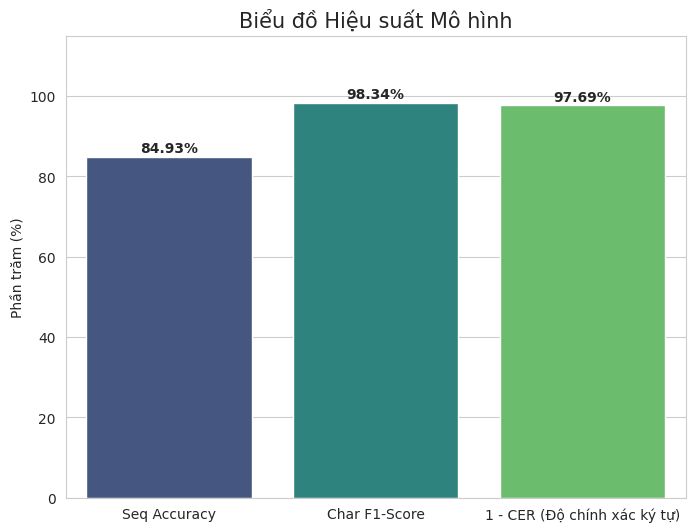


📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...
✅ Đã lưu Ma trận nhầm lẫn tại: /content/drive/MyDrive/crnn_licenseplate/confusion_matrix_errors.png


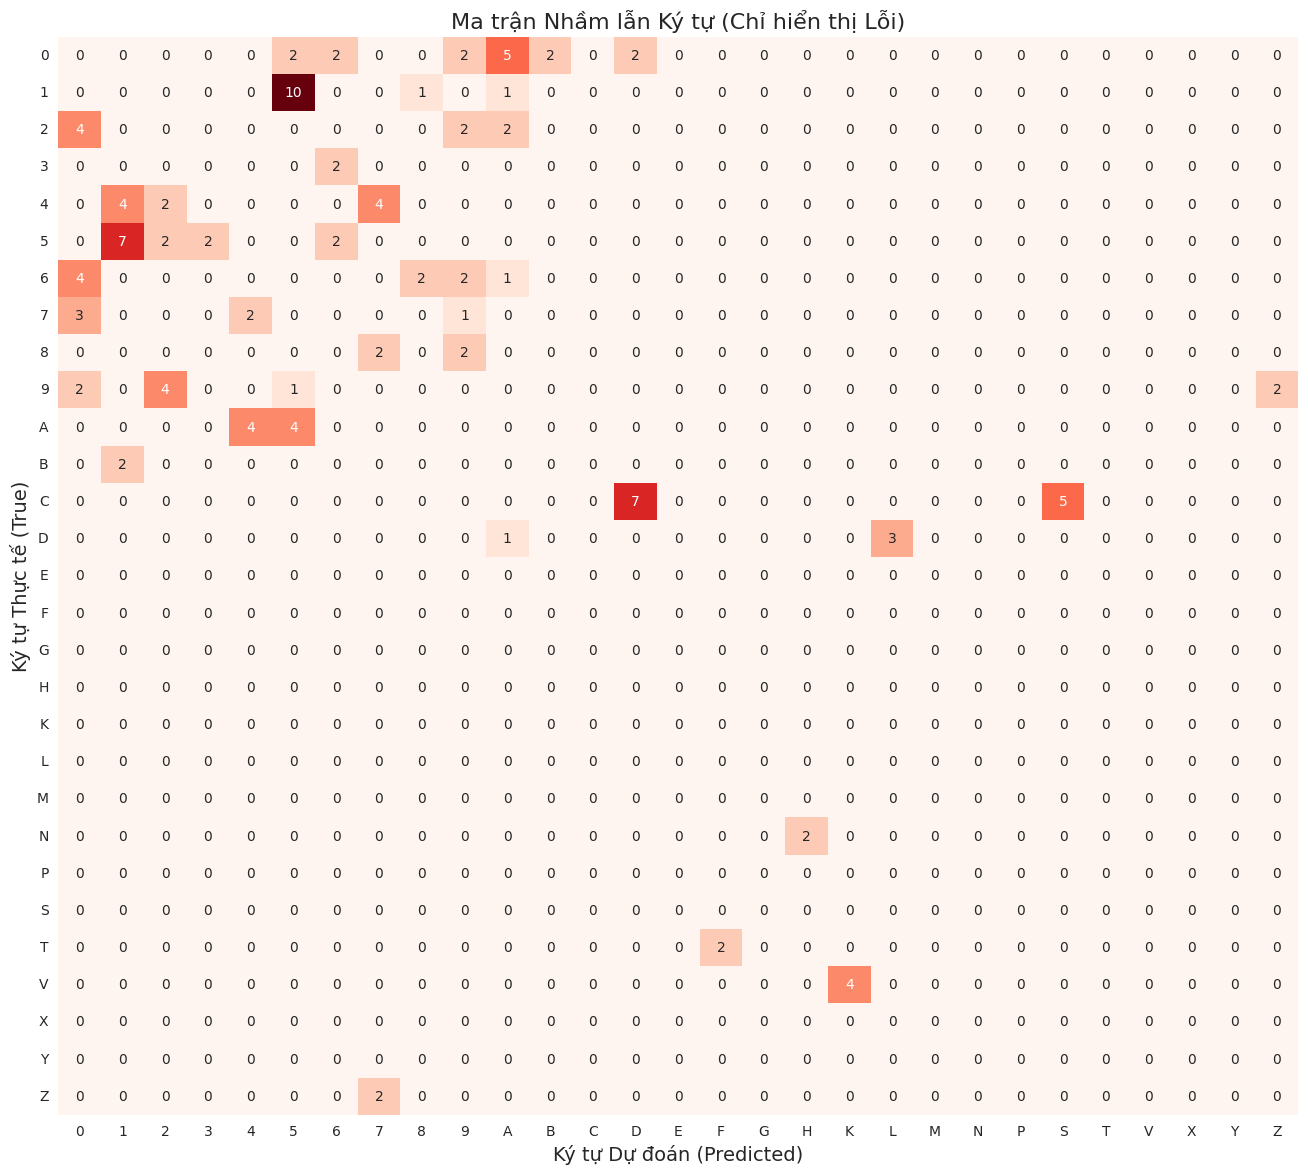


🚨 TOP CÁC CẶP KÝ TỰ BỊ NHẦM LẪN NHIỀU NHẤT:
   ❌ Thực tế '1'  -->  Dự đoán '5': 10 lần
   ❌ Thực tế '5'  -->  Dự đoán '1': 7 lần
   ❌ Thực tế 'C'  -->  Dự đoán 'D': 7 lần
   ❌ Thực tế 'C'  -->  Dự đoán 'S': 5 lần
   ❌ Thực tế '0'  -->  Dự đoán 'A': 5 lần
   ❌ Thực tế 'V'  -->  Dự đoán 'K': 4 lần
   ❌ Thực tế '2'  -->  Dự đoán '0': 4 lần
   ❌ Thực tế '9'  -->  Dự đoán '2': 4 lần
   ❌ Thực tế 'A'  -->  Dự đoán '4': 4 lần
   ❌ Thực tế 'A'  -->  Dự đoán '5': 4 lần


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import editdistance
from tqdm import tqdm
import difflib
from sklearn.metrics import confusion_matrix

# =============================================================================
# 1. CẤU HÌNH VÀ TẢI MÔ HÌNH
# =============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
# Thay bằng tên model bạn muốn đánh giá
MODEL_FILE = "best_model_optimized_front.pth"
model_path = f"{output_dir}/{MODEL_FILE}"

print(f"📊 ĐANG TẢI MÔ HÌNH TỪ: {model_path}")

checkpoint = torch.load(model_path, map_location=device)
model_eval = CRNN(num_classes=len(checkpoint['idx_to_char']), hidden_size=256, pretrained=False).to(device)
model_eval.load_state_dict(checkpoint['model_state_dict'])
model_eval.eval()
idx_to_char = checkpoint['idx_to_char']

def decode_predictions(outputs):
    _, preds = torch.max(outputs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# =============================================================================
# 2. TÍNH TOÁN VÀ THU THẬP DỮ LIỆU LỖI (CONFUSION MATRIX)
# =============================================================================
print("\n🚀 Đang chạy đánh giá và phân tích lỗi ký tự...")

total_samples = 0
exact_matches = 0
total_char_dist = 0
total_chars_true = 0
total_chars_pred = 0
total_correct_chars = 0

# Lists để vẽ Confusion Matrix
y_true_chars = []
y_pred_chars = []

# Danh sách các ký tự quan tâm (Để vẽ ma trận không bị quá lớn)
# Chỉ lấy các ký tự chữ và số (Bỏ các ký tự đặc biệt nếu có)
vocab_chars = sorted([c for c in idx_to_char.values() if c.isalnum()])

with torch.no_grad():
    for batch in tqdm(val_loader):
        if batch is None: continue

        images = batch["images"].to(device)
        texts = batch["texts"]

        outputs = model_eval(images)
        preds = decode_predictions(outputs)

        for pred, target in zip(preds, texts):
            total_samples += 1

            # 1. Accuracy
            if pred == target: exact_matches += 1

            # 2. CER
            dist = editdistance.eval(pred, target)
            total_char_dist += dist
            total_chars_true += len(target)
            total_chars_pred += len(pred)

            # 3. F1 Score prep
            s = difflib.SequenceMatcher(None, pred, target)
            matches = sum(n for i, j, n in s.get_matching_blocks())
            total_correct_chars += matches

            # 4. Thu thập dữ liệu cho Confusion Matrix (Chỉ khi độ dài bằng nhau để đơn giản hóa)
            # Với OCR, việc căn chỉnh (alignment) chính xác từng ký tự khi độ dài khác nhau rất phức tạp.
            # Ở đây ta dùng mẹo: Chỉ so sánh các cặp ký tự ở cùng vị trí nếu độ dài chuỗi bằng nhau (hoặc cắt ngắn).
            # Cách này giúp phát hiện các lỗi thay thế (Substitution) phổ biến nhất (G->B, 8->B).
            min_len = min(len(pred), len(target))
            for i in range(min_len):
                y_true_chars.append(target[i])
                y_pred_chars.append(pred[i])

# --- TỔNG HỢP KẾT QUẢ ---
seq_accuracy = (exact_matches / total_samples) * 100
ser = 100 - seq_accuracy
cer = (total_char_dist / total_chars_true) * 100

# F1 Score
precision = total_correct_chars / total_chars_pred if total_chars_pred > 0 else 0
recall = total_correct_chars / total_chars_true if total_chars_true > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
f1_score *= 100

print("\n" + "="*60)
print(f"🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("="*60)
print(f"1. Sequence Accuracy:  {seq_accuracy:.2f}%")
print(f"2. Character F1-Score: {f1_score:.2f}%")
print(f"3. CER (Lỗi ký tự):    {cer:.2f}%")
print("="*60)

# =============================================================================
# 3. VẼ BIỂU ĐỒ CỘT (METRICS)
# =============================================================================
metrics_df = pd.DataFrame({
    'Metric': ['Seq Accuracy', 'Char F1-Score', '1 - CER (Độ chính xác ký tự)'],
    'Score': [seq_accuracy, f1_score, 100 - cer]
})

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.2f}%', ha="center", fontweight='bold')
plt.ylim(0, 115)
plt.title('Biểu đồ Hiệu suất Mô hình', fontsize=15)
plt.ylabel('Phần trăm (%)')
plt.xlabel('')
save_chart_path = f"{output_dir}/evaluation_metrics_chart.png"
plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ cột tại: {save_chart_path}")
plt.show()

# =============================================================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX HEATMAP)
# =============================================================================
print("\n📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...")

# Tạo ma trận
cm = confusion_matrix(y_true_chars, y_pred_chars, labels=vocab_chars)

# Chuẩn hóa (Normalize) để xem tỷ lệ phần trăm lỗi (dễ so sánh hơn số lượng tuyệt đối)
# Tuy nhiên, đường chéo chính (đúng) sẽ rất lớn, làm mờ các lỗi.
# Mẹo: Chúng ta sẽ xoá đường chéo chính (gán bằng 0) để CHỈ LÀM NỔI BẬT CÁC LỖI.
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0) # Xóa các trường hợp dự đoán đúng

# Vẽ Heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds',
            xticklabels=vocab_chars, yticklabels=vocab_chars, cbar=False)

plt.title('Ma trận Nhầm lẫn Ký tự (Chỉ hiển thị Lỗi)', fontsize=16)
plt.xlabel('Ký tự Dự đoán (Predicted)', fontsize=14)
plt.ylabel('Ký tự Thực tế (True)', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

save_cm_path = f"{output_dir}/confusion_matrix_errors.png"
plt.savefig(save_cm_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu Ma trận nhầm lẫn tại: {save_cm_path}")
plt.show()

# In ra Top các cặp lỗi
print("\n🚨 TOP CÁC CẶP KÝ TỰ BỊ NHẦM LẪN NHIỀU NHẤT:")
# Tìm index của các giá trị lớn nhất trong ma trận lỗi
# (Làm phẳng ma trận -> sắp xếp -> lấy index -> chuyển lại tọa độ 2D)
flat_indices = np.argsort(cm_errors.flatten())[::-1] # Sắp xếp giảm dần
top_n = 10

for i in range(top_n):
    idx = flat_indices[i]
    row, col = divmod(idx, len(vocab_chars))
    count = cm_errors[row, col]
    if count > 0:
        true_char = vocab_chars[row]
        pred_char = vocab_chars[col]
        print(f"   ❌ Thực tế '{true_char}'  -->  Dự đoán '{pred_char}': {count} lần")

📊 ĐANG TẢI MÔ HÌNH TỪ: /content/drive/MyDrive/crnn_licenseplate/best_model_FINAL_robust_v2.pth

🚀 Đang chạy đánh giá và phân tích lỗi ký tự...


100%|██████████| 17/17 [00:01<00:00,  9.96it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
1. Sequence Accuracy:  78.68%
2. Character F1-Score: 97.87%
3. CER (Lỗi ký tự):    3.14%
✅ Đã lưu biểu đồ cột tại: /content/drive/MyDrive/crnn_licenseplate/evaluation_metrics_chart.png


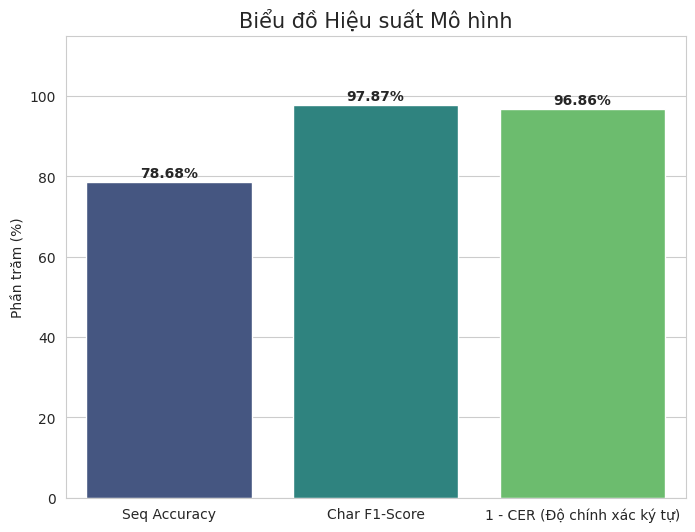


📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...
✅ Đã lưu Ma trận nhầm lẫn tại: /content/drive/MyDrive/crnn_licenseplate/confusion_matrix_errors.png


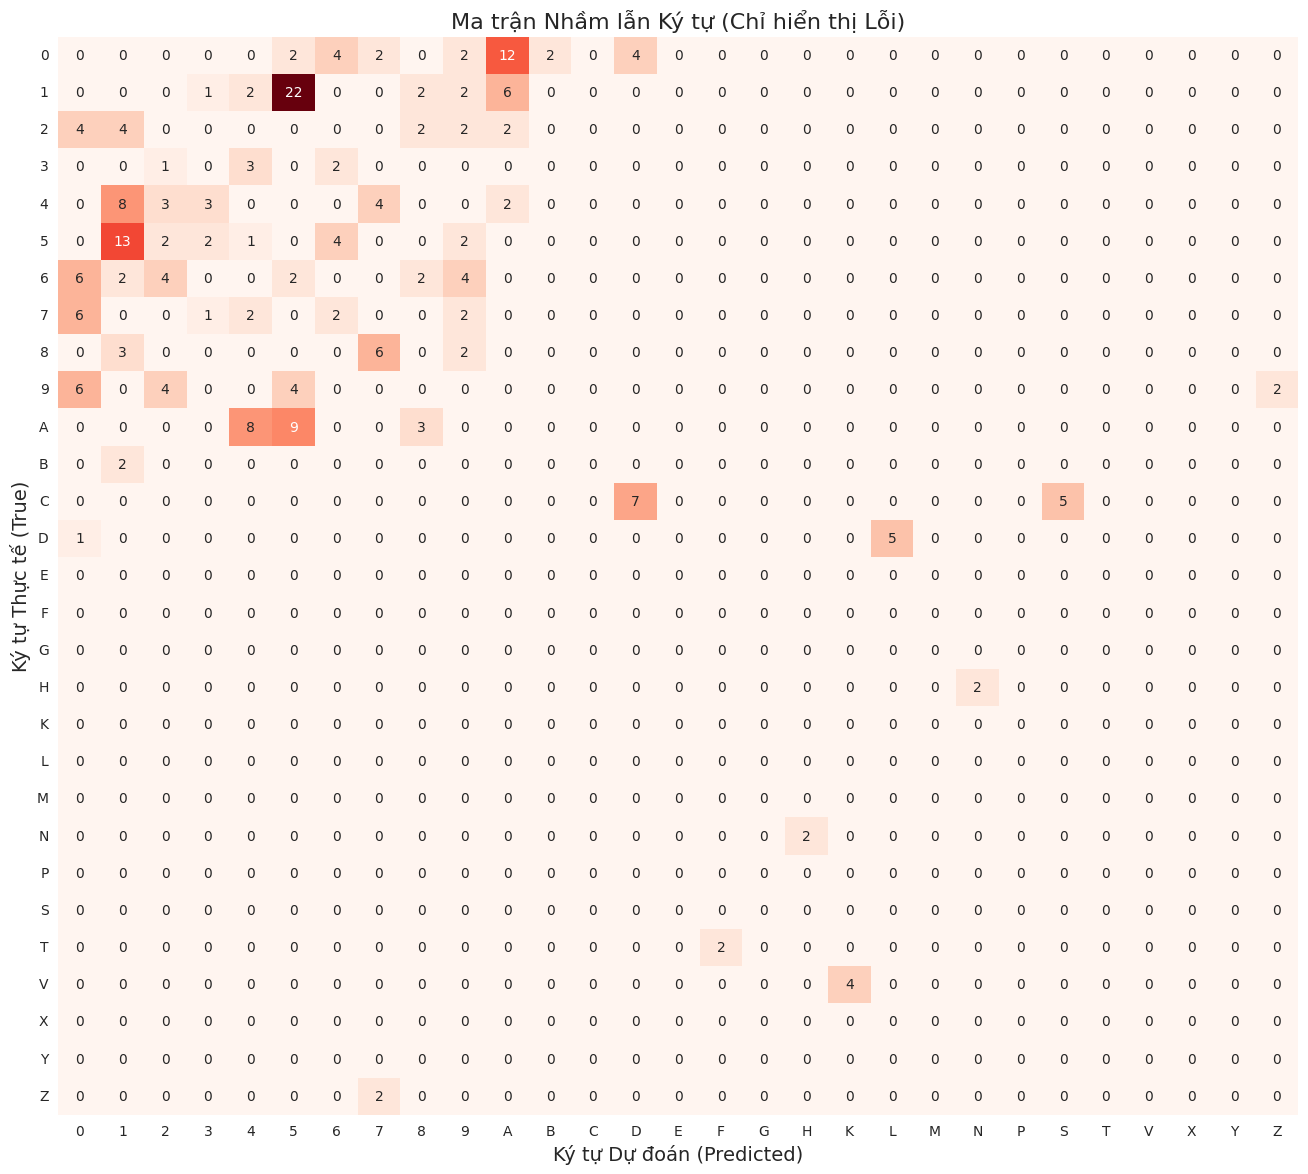


🚨 TOP CÁC CẶP KÝ TỰ BỊ NHẦM LẪN NHIỀU NHẤT:
   ❌ Thực tế '1'  -->  Dự đoán '5': 22 lần
   ❌ Thực tế '5'  -->  Dự đoán '1': 13 lần
   ❌ Thực tế '0'  -->  Dự đoán 'A': 12 lần
   ❌ Thực tế 'A'  -->  Dự đoán '5': 9 lần
   ❌ Thực tế 'A'  -->  Dự đoán '4': 8 lần
   ❌ Thực tế '4'  -->  Dự đoán '1': 8 lần
   ❌ Thực tế 'C'  -->  Dự đoán 'D': 7 lần
   ❌ Thực tế '9'  -->  Dự đoán '0': 6 lần
   ❌ Thực tế '8'  -->  Dự đoán '7': 6 lần
   ❌ Thực tế '6'  -->  Dự đoán '0': 6 lần


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import editdistance
from tqdm import tqdm
import difflib
from sklearn.metrics import confusion_matrix

# =============================================================================
# 1. CẤU HÌNH VÀ TẢI MÔ HÌNH
# =============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
# Thay bằng tên model bạn muốn đánh giá
MODEL_FILE = "best_model_FINAL_robust_v2.pth"
model_path = f"{output_dir}/{MODEL_FILE}"

print(f"📊 ĐANG TẢI MÔ HÌNH TỪ: {model_path}")

checkpoint = torch.load(model_path, map_location=device)
model_eval = CRNN(num_classes=len(checkpoint['idx_to_char']), hidden_size=256, pretrained=False).to(device)
model_eval.load_state_dict(checkpoint['model_state_dict'])
model_eval.eval()
idx_to_char = checkpoint['idx_to_char']

def decode_predictions(outputs):
    _, preds = torch.max(outputs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# =============================================================================
# 2. TÍNH TOÁN VÀ THU THẬP DỮ LIỆU LỖI (CONFUSION MATRIX)
# =============================================================================
print("\n🚀 Đang chạy đánh giá và phân tích lỗi ký tự...")

total_samples = 0
exact_matches = 0
total_char_dist = 0
total_chars_true = 0
total_chars_pred = 0
total_correct_chars = 0

# Lists để vẽ Confusion Matrix
y_true_chars = []
y_pred_chars = []

# Danh sách các ký tự quan tâm (Để vẽ ma trận không bị quá lớn)
# Chỉ lấy các ký tự chữ và số (Bỏ các ký tự đặc biệt nếu có)
vocab_chars = sorted([c for c in idx_to_char.values() if c.isalnum()])

with torch.no_grad():
    for batch in tqdm(val_loader):
        if batch is None: continue

        images = batch["images"].to(device)
        texts = batch["texts"]

        outputs = model_eval(images)
        preds = decode_predictions(outputs)

        for pred, target in zip(preds, texts):
            total_samples += 1

            # 1. Accuracy
            if pred == target: exact_matches += 1

            # 2. CER
            dist = editdistance.eval(pred, target)
            total_char_dist += dist
            total_chars_true += len(target)
            total_chars_pred += len(pred)

            # 3. F1 Score prep
            s = difflib.SequenceMatcher(None, pred, target)
            matches = sum(n for i, j, n in s.get_matching_blocks())
            total_correct_chars += matches

            # 4. Thu thập dữ liệu cho Confusion Matrix (Chỉ khi độ dài bằng nhau để đơn giản hóa)
            # Với OCR, việc căn chỉnh (alignment) chính xác từng ký tự khi độ dài khác nhau rất phức tạp.
            # Ở đây ta dùng mẹo: Chỉ so sánh các cặp ký tự ở cùng vị trí nếu độ dài chuỗi bằng nhau (hoặc cắt ngắn).
            # Cách này giúp phát hiện các lỗi thay thế (Substitution) phổ biến nhất (G->B, 8->B).
            min_len = min(len(pred), len(target))
            for i in range(min_len):
                y_true_chars.append(target[i])
                y_pred_chars.append(pred[i])

# --- TỔNG HỢP KẾT QUẢ ---
seq_accuracy = (exact_matches / total_samples) * 100
ser = 100 - seq_accuracy
cer = (total_char_dist / total_chars_true) * 100

# F1 Score
precision = total_correct_chars / total_chars_pred if total_chars_pred > 0 else 0
recall = total_correct_chars / total_chars_true if total_chars_true > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
f1_score *= 100

print("\n" + "="*60)
print(f"🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("="*60)
print(f"1. Sequence Accuracy:  {seq_accuracy:.2f}%")
print(f"2. Character F1-Score: {f1_score:.2f}%")
print(f"3. CER (Lỗi ký tự):    {cer:.2f}%")
print("="*60)

# =============================================================================
# 3. VẼ BIỂU ĐỒ CỘT (METRICS)
# =============================================================================
metrics_df = pd.DataFrame({
    'Metric': ['Seq Accuracy', 'Char F1-Score', '1 - CER (Độ chính xác ký tự)'],
    'Score': [seq_accuracy, f1_score, 100 - cer]
})

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.2f}%', ha="center", fontweight='bold')
plt.ylim(0, 115)
plt.title('Biểu đồ Hiệu suất Mô hình', fontsize=15)
plt.ylabel('Phần trăm (%)')
plt.xlabel('')
save_chart_path = f"{output_dir}/evaluation_metrics_chart.png"
plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ cột tại: {save_chart_path}")
plt.show()

# =============================================================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX HEATMAP)
# =============================================================================
print("\n📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...")

# Tạo ma trận
cm = confusion_matrix(y_true_chars, y_pred_chars, labels=vocab_chars)

# Chuẩn hóa (Normalize) để xem tỷ lệ phần trăm lỗi (dễ so sánh hơn số lượng tuyệt đối)
# Tuy nhiên, đường chéo chính (đúng) sẽ rất lớn, làm mờ các lỗi.
# Mẹo: Chúng ta sẽ xoá đường chéo chính (gán bằng 0) để CHỈ LÀM NỔI BẬT CÁC LỖI.
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0) # Xóa các trường hợp dự đoán đúng

# Vẽ Heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds',
            xticklabels=vocab_chars, yticklabels=vocab_chars, cbar=False)

plt.title('Ma trận Nhầm lẫn Ký tự (Chỉ hiển thị Lỗi)', fontsize=16)
plt.xlabel('Ký tự Dự đoán (Predicted)', fontsize=14)
plt.ylabel('Ký tự Thực tế (True)', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

save_cm_path = f"{output_dir}/confusion_matrix_errors.png"
plt.savefig(save_cm_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu Ma trận nhầm lẫn tại: {save_cm_path}")
plt.show()

# In ra Top các cặp lỗi
print("\n🚨 TOP CÁC CẶP KÝ TỰ BỊ NHẦM LẪN NHIỀU NHẤT:")
# Tìm index của các giá trị lớn nhất trong ma trận lỗi
# (Làm phẳng ma trận -> sắp xếp -> lấy index -> chuyển lại tọa độ 2D)
flat_indices = np.argsort(cm_errors.flatten())[::-1] # Sắp xếp giảm dần
top_n = 10

for i in range(top_n):
    idx = flat_indices[i]
    row, col = divmod(idx, len(vocab_chars))
    count = cm_errors[row, col]
    if count > 0:
        true_char = vocab_chars[row]
        pred_char = vocab_chars[col]
        print(f"   ❌ Thực tế '{true_char}'  -->  Dự đoán '{pred_char}': {count} lần")

In [ ]:
!pip install editdistance seaborn matplotlib pandas -q

📊 ĐANG TẢI MÔ HÌNH TỪ: /content/drive/MyDrive/crnn_licenseplate/best_model.pth

🚀 Đang chạy đánh giá trên tập Validation...


100%|██████████| 17/17 [00:02<00:00,  6.02it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (Trên 272 ảnh validation)
1. Sequence Accuracy (Độ chính xác biển số):  84.56%
2. SER (Tỷ lệ lỗi biển số):                   15.44%
------------------------------------------------------------
3. CER (Tỷ lệ lỗi ký tự - Quan trọng nhất):   2.26%
   (Thấp hơn là tốt hơn)
------------------------------------------------------------
4. Chỉ số cấp ký tự (Character-Level Metrics):
   - Precision (Độ chính xác):                97.93%
   - Recall (Độ phủ):                         98.11%
   - F1-Score:                                98.02%

✅ Đã lưu biểu đồ đánh giá tại: /content/drive/MyDrive/crnn_licenseplate/evaluation_metrics_chart.png


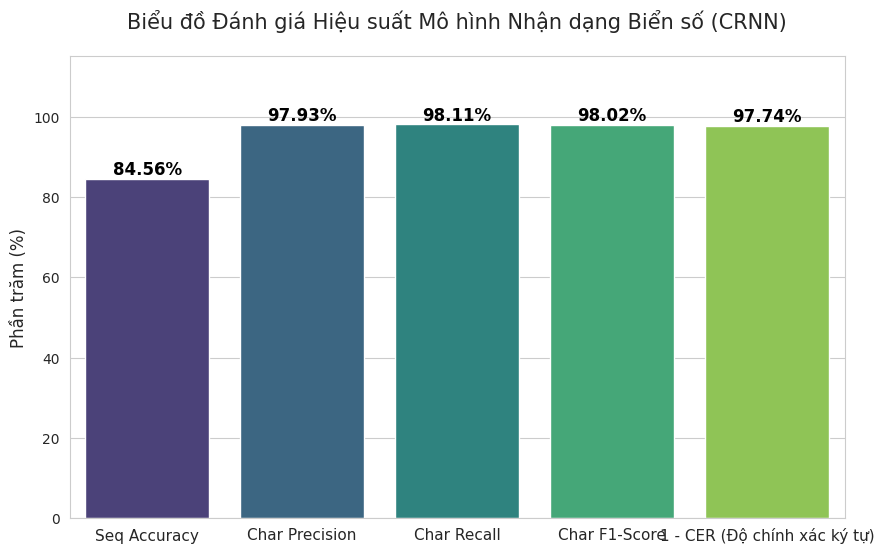

✅ Đã lưu biểu đồ tròn tại: /content/drive/MyDrive/crnn_licenseplate/evaluation_pie_chart.png


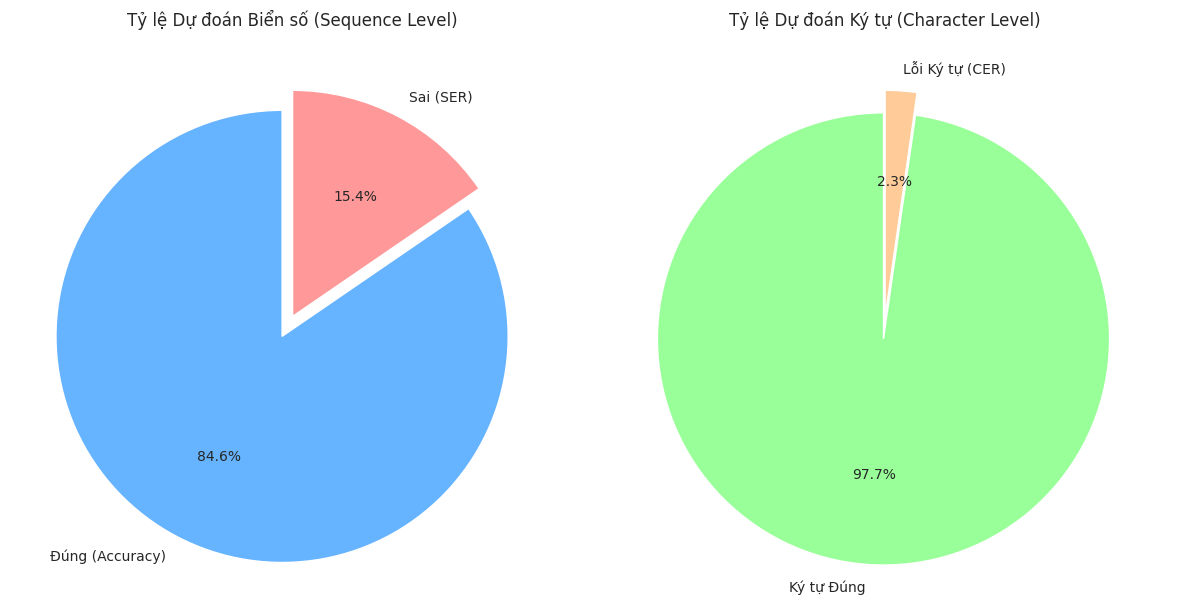

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import editdistance # Thư viện tính khoảng cách chỉnh sửa chuẩn xác
from tqdm import tqdm
import difflib # Để tính toán khớp ký tự cho F1

# =============================================================================
# 1. CẤU HÌNH VÀ TẢI MÔ HÌNH TỐT NHẤT
# =============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = f"{output_dir}/best_model.pth"

print(f"📊 ĐANG TẢI MÔ HÌNH TỪ: {model_path}")

# Tải checkpoint
checkpoint = torch.load(model_path, map_location=device)

# Khởi tạo lại model (đảm bảo cấu trúc giống hệt lúc train)
model_eval = CRNN(num_classes=len(checkpoint['char_to_idx']), hidden_size=256, pretrained=False).to(device)
model_eval.load_state_dict(checkpoint['model_state_dict'])
model_eval.eval()

# Lấy từ điển ánh xạ
idx_to_char = checkpoint['idx_to_char']

# Hàm giải mã (Greedy Decode)
def decode_predictions(outputs):
    _, preds = torch.max(outputs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0: # 0 là blank
                chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# =============================================================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ (METRICS)
# =============================================================================
print("\n🚀 Đang chạy đánh giá trên tập Validation...")

total_samples = 0
exact_matches = 0       # Số biển số đúng hoàn toàn
total_char_dist = 0     # Tổng khoảng cách chỉnh sửa (cho CER)
total_chars_true = 0    # Tổng số ký tự thực tế
total_chars_pred = 0    # Tổng số ký tự dự đoán
total_correct_chars = 0 # Tổng số ký tự khớp đúng vị trí (cho F1)

with torch.no_grad():
    for batch in tqdm(val_loader):
        if batch is None: continue

        images = batch["images"].to(device)
        texts = batch["texts"] # Ground Truth

        outputs = model_eval(images)
        preds = decode_predictions(outputs)

        for pred, target in zip(preds, texts):
            total_samples += 1

            # 1. Sequence Accuracy (Đúng tuyệt đối)
            if pred == target:
                exact_matches += 1

            # 2. CER (Dựa trên Edit Distance)
            dist = editdistance.eval(pred, target)
            total_char_dist += dist
            total_chars_true += len(target)
            total_chars_pred += len(pred)

            # 3. Tính toán cho F1/Precision/Recall (Sử dụng SequenceMatcher)
            # Tìm số ký tự khớp nhau (Longest Common Subsequence)
            s = difflib.SequenceMatcher(None, pred, target)
            matches = sum(n for i, j, n in s.get_matching_blocks())
            total_correct_chars += matches

# --- TỔNG HỢP KẾT QUẢ ---

# A. Sequence Level
seq_accuracy = (exact_matches / total_samples) * 100
ser = 100 - seq_accuracy # Sequence Error Rate

# B. Character Level (CER)
cer = (total_char_dist / total_chars_true) * 100

# C. Character Level (F1, Precision, Recall)
# Precision = Ký tự đúng / Tổng ký tự dự đoán
precision = total_correct_chars / total_chars_pred if total_chars_pred > 0 else 0
# Recall = Ký tự đúng / Tổng ký tự thực tế
recall = total_correct_chars / total_chars_true if total_chars_true > 0 else 0
# F1 Score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Chuyển sang %
precision *= 100
recall *= 100
f1_score *= 100

# In kết quả dạng bảng text
print("\n" + "="*60)
print(f"🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (Trên {total_samples} ảnh validation)")
print("="*60)
print(f"1. Sequence Accuracy (Độ chính xác biển số):  {seq_accuracy:.2f}%")
print(f"2. SER (Tỷ lệ lỗi biển số):                   {ser:.2f}%")
print("-" * 60)
print(f"3. CER (Tỷ lệ lỗi ký tự - Quan trọng nhất):   {cer:.2f}%")
print(f"   (Thấp hơn là tốt hơn)")
print("-" * 60)
print(f"4. Chỉ số cấp ký tự (Character-Level Metrics):")
print(f"   - Precision (Độ chính xác):                {precision:.2f}%")
print(f"   - Recall (Độ phủ):                         {recall:.2f}%")
print(f"   - F1-Score:                                {f1_score:.2f}%")
print("="*60)

# =============================================================================
# 3. VẼ BIỂU ĐỒ (VISUALIZATION)
# =============================================================================

# Tạo DataFrame để vẽ
metrics_df = pd.DataFrame({
    'Metric': ['Seq Accuracy', 'Char Precision', 'Char Recall', 'Char F1-Score', '1 - CER (Độ chính xác ký tự)'],
    'Score': [seq_accuracy, precision, recall, f1_score, 100 - cer]
})

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Vẽ biểu đồ cột
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')

# Thêm số liệu lên đầu cột
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1,
            f'{height:.2f}%', ha="center", fontsize=12, fontweight='bold', color='black')

plt.ylim(0, 115) # Để khoảng trống phía trên
plt.title('Biểu đồ Đánh giá Hiệu suất Mô hình Nhận dạng Biển số (CRNN)', fontsize=15, pad=20)
plt.ylabel('Phần trăm (%)', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11)

# Lưu biểu đồ
save_chart_path = f"{output_dir}/evaluation_metrics_chart.png"
plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Đã lưu biểu đồ đánh giá tại: {save_chart_path}")
plt.show()

# Vẽ biểu đồ Confusion Matrix cho CER và Accuracy (Dạng Pie Chart đơn giản)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Biểu đồ 1: Sequence Accuracy vs SER
ax1.pie([seq_accuracy, ser], labels=['Đúng (Accuracy)', 'Sai (SER)'],
        autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.1, 0))
ax1.set_title('Tỷ lệ Dự đoán Biển số (Sequence Level)')

# Biểu đồ 2: Character Accuracy vs CER
ax2.pie([100-cer, cer], labels=['Ký tự Đúng', 'Lỗi Ký tự (CER)'],
        autopct='%1.1f%%', colors=['#99ff99','#ffcc99'], startangle=90, explode=(0.1, 0))
ax2.set_title('Tỷ lệ Dự đoán Ký tự (Character Level)')

plt.tight_layout()
save_pie_path = f"{output_dir}/evaluation_pie_chart.png"
plt.savefig(save_pie_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ tròn tại: {save_pie_path}")
plt.show()

📊 ĐANG TẢI MÔ HÌNH TỪ: /content/drive/MyDrive/crnn_licenseplate/best_model_optimized_front.pth

🚀 Đang chạy đánh giá...


100%|██████████| 17/17 [00:01<00:00, 10.87it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT
1. Sequence Accuracy (Độ chính xác biển số):  84.93%
👉 SER (Tỷ lệ biển số bị sai):                 15.07%
------------------------------------------------------------
2. Character F1-Score:                        98.34%
3. CER (Lỗi ký tự trung bình):                2.31%


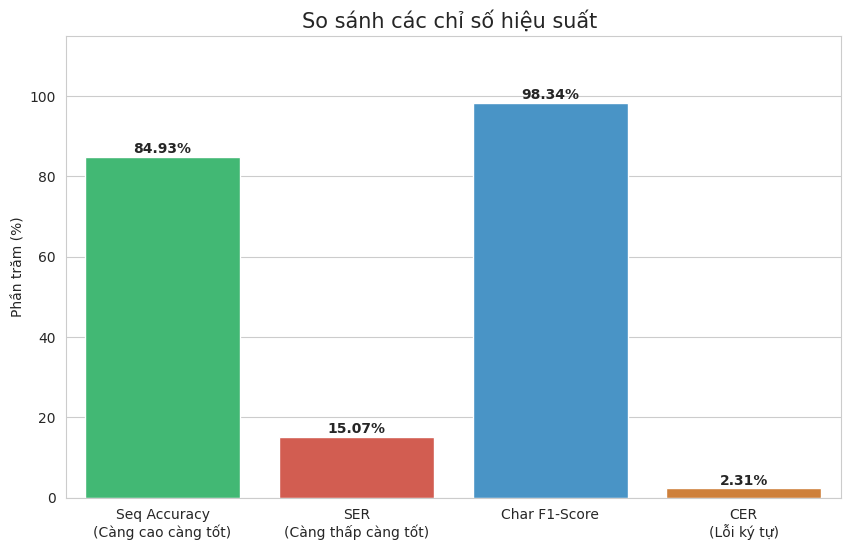

✅ Đã lưu biểu đồ tròn SER tại: /content/drive/MyDrive/crnn_licenseplate/accuracy_vs_ser_pie.png


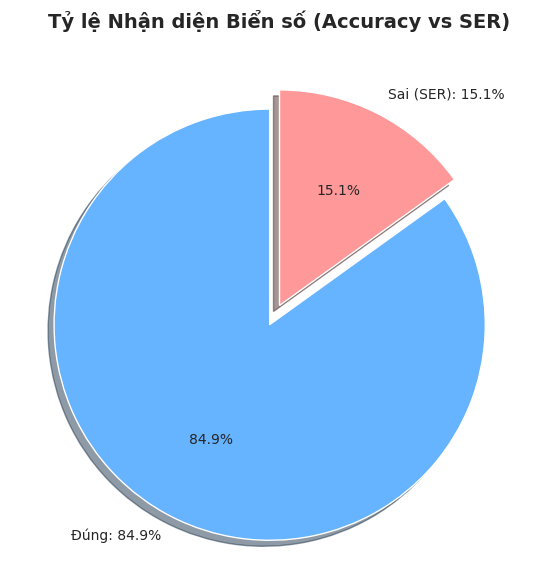


📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...


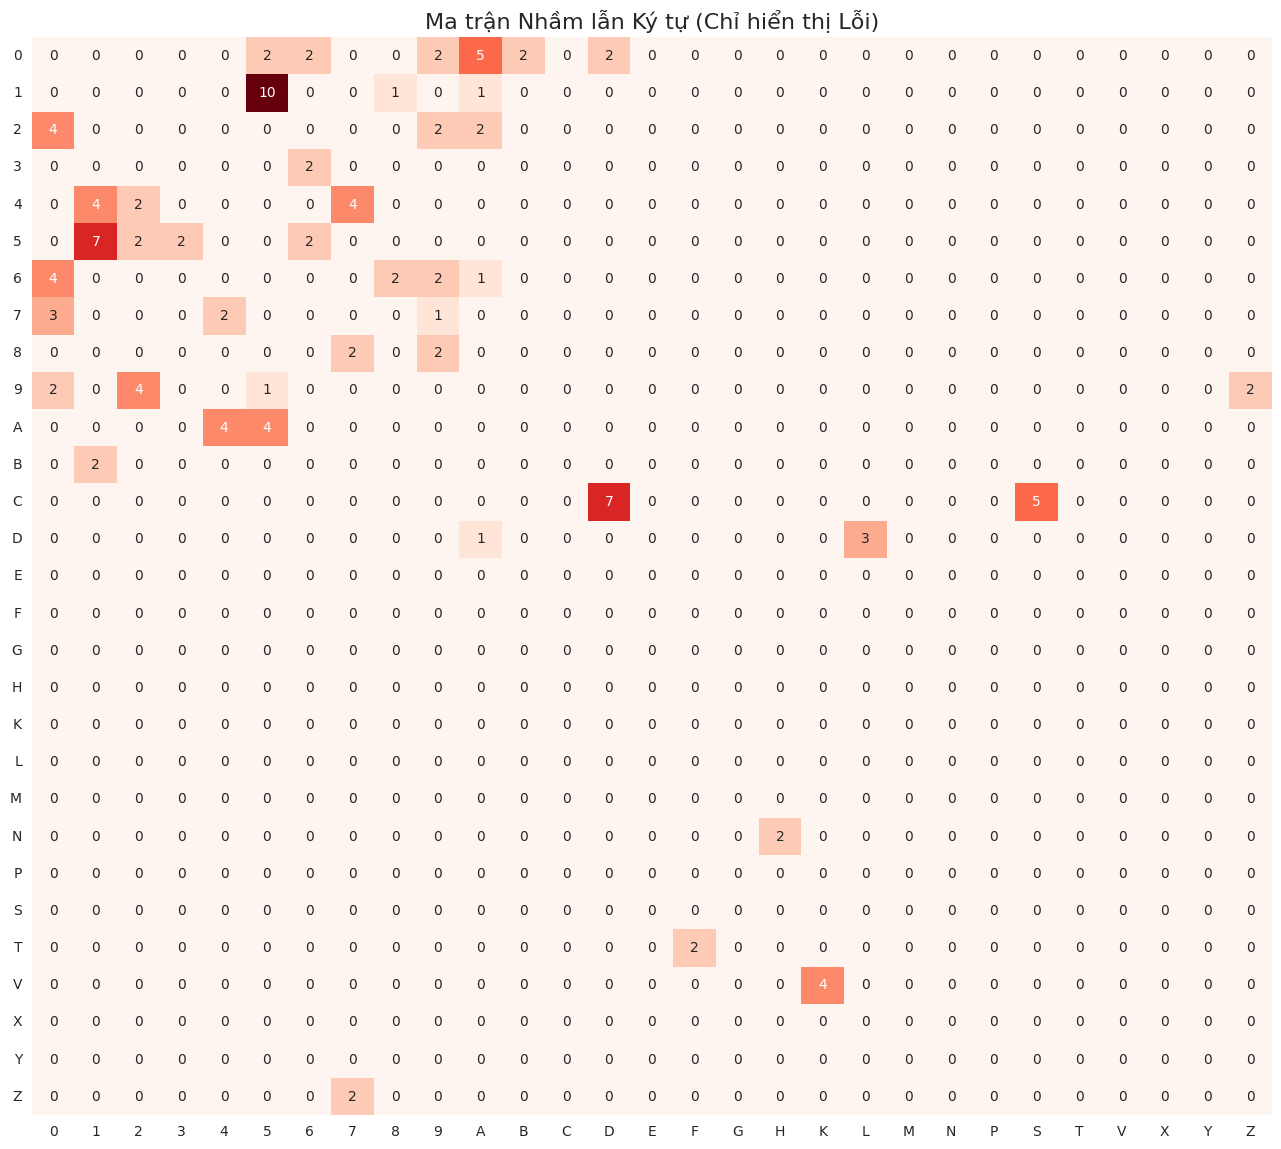

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import editdistance
from tqdm import tqdm
import difflib
from sklearn.metrics import confusion_matrix
import os

# =============================================================================
# 1. CẤU HÌNH VÀ TẢI MÔ HÌNH
# =============================================================================
# Giả lập đường dẫn output_dir và val_loader nếu chạy độc lập (Bạn có thể xóa nếu chạy trong notebook cũ)
# output_dir = "/content/drive/MyDrive/crnn_licenseplate"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Tên model bạn muốn đánh giá
MODEL_FILE = "best_model_optimized_front.pth"
model_path = f"{output_dir}/{MODEL_FILE}"

print(f"📊 ĐANG TẢI MÔ HÌNH TỪ: {model_path}")

if not os.path.exists(model_path):
    print(f"❌ Lỗi: Không tìm thấy file {model_path}")
else:
    checkpoint = torch.load(model_path, map_location=device)
    # Khởi tạo model (đảm bảo class CRNN đã được định nghĩa trước đó)
    model_eval = CRNN(num_classes=len(checkpoint['idx_to_char']), hidden_size=256, pretrained=False).to(device)
    model_eval.load_state_dict(checkpoint['model_state_dict'])
    model_eval.eval()
    idx_to_char = checkpoint['idx_to_char']

    def decode_predictions(outputs):
        _, preds = torch.max(outputs, dim=2)
        preds = preds.permute(1, 0)
        decoded = []
        for pred in preds:
            chars = []
            prev = -1
            for p in pred:
                p = p.item()
                if p != prev and p != 0:
                    chars.append(idx_to_char[p])
                prev = p
            decoded.append(''.join(chars))
        return decoded

    # =============================================================================
    # 2. TÍNH TOÁN CÁC CHỈ SỐ (BAO GỒM SER)
    # =============================================================================
    print("\n🚀 Đang chạy đánh giá...")

    total_samples = 0
    exact_matches = 0
    total_char_dist = 0
    total_chars_true = 0
    total_chars_pred = 0
    total_correct_chars = 0

    # Lists để vẽ Confusion Matrix
    y_true_chars = []
    y_pred_chars = []
    vocab_chars = sorted([c for c in idx_to_char.values() if c.isalnum()])

    with torch.no_grad():
        for batch in tqdm(val_loader):
            if batch is None: continue

            images = batch["images"].to(device)
            texts = batch["texts"]

            outputs = model_eval(images)
            preds = decode_predictions(outputs)

            for pred, target in zip(preds, texts):
                total_samples += 1

                # 1. Accuracy (Đúng tuyệt đối cả chuỗi)
                if pred == target: exact_matches += 1

                # 2. CER (Lỗi ký tự)
                dist = editdistance.eval(pred, target)
                total_char_dist += dist
                total_chars_true += len(target)
                total_chars_pred += len(pred)

                # 3. F1 Score prep
                s = difflib.SequenceMatcher(None, pred, target)
                matches = sum(n for i, j, n in s.get_matching_blocks())
                total_correct_chars += matches

                # 4. Data cho Confusion Matrix
                min_len = min(len(pred), len(target))
                for i in range(min_len):
                    y_true_chars.append(target[i])
                    y_pred_chars.append(pred[i])

    # --- TỔNG HỢP KẾT QUẢ ---
    # Tỷ lệ đoán đúng cả biển
    seq_accuracy = (exact_matches / total_samples) * 100

    # ✅ TÍNH SER (SEQUENCE ERROR RATE)
    ser = 100 - seq_accuracy

    # Tỷ lệ lỗi ký tự
    cer = (total_char_dist / total_chars_true) * 100

    # F1 Score
    precision = total_correct_chars / total_chars_pred if total_chars_pred > 0 else 0
    recall = total_correct_chars / total_chars_true if total_chars_true > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_score *= 100

    print("\n" + "="*60)
    print(f"🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT")
    print("="*60)
    print(f"1. Sequence Accuracy (Độ chính xác biển số):  {seq_accuracy:.2f}%")
    print(f"👉 SER (Tỷ lệ biển số bị sai):                 {ser:.2f}%")  # Đã thêm dòng này
    print("-" * 60)
    print(f"2. Character F1-Score:                        {f1_score:.2f}%")
    print(f"3. CER (Lỗi ký tự trung bình):                {cer:.2f}%")
    print("="*60)

    # =============================================================================
    # 3. VẼ BIỂU ĐỒ CỘT (CẬP NHẬT SER)
    # =============================================================================
    # Thêm SER vào DataFrame để vẽ
    metrics_df = pd.DataFrame({
        'Metric': ['Seq Accuracy\n(Càng cao càng tốt)', 'SER\n(Càng thấp càng tốt)', 'Char F1-Score', 'CER\n(Lỗi ký tự)'],
        'Score': [seq_accuracy, ser, f1_score, cer]
    })

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Vẽ biểu đồ với màu sắc khác biệt cho các chỉ số Tốt (Xanh) và Xấu (Đỏ)
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22'] # Xanh lá, Đỏ, Xanh dương, Cam
    ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette=colors)

    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.2f}%', ha="center", fontweight='bold')

    plt.ylim(0, 115)
    plt.title('So sánh các chỉ số hiệu suất ', fontsize=15)
    plt.ylabel('Phần trăm (%)')
    plt.xlabel('')

    save_chart_path = f"{output_dir}/evaluation_metrics_chart.png"
    plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
    plt.show()

    # =============================================================================
    # 3.1. VẼ BIỂU ĐỒ TRÒN (PIE CHART) CHO ACCURACY vs SER
    # =============================================================================
    # Biểu đồ này trực quan nhất để thấy tỷ lệ Sai (SER) so với Đúng
    plt.figure(figsize=(7, 7))
    labels = [f'Đúng: {seq_accuracy:.1f}%', f'Sai (SER): {ser:.1f}%']
    sizes = [seq_accuracy, ser]
    colors_pie = ['#66b3ff', '#ff9999'] # Xanh và Đỏ nhạt
    explode = (0.1, 0)  # Tách phần "Đúng" ra một chút

    plt.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90)
    plt.title("Tỷ lệ Nhận diện Biển số (Accuracy vs SER)", fontsize=14, fontweight='bold')

    save_pie_path = f"{output_dir}/accuracy_vs_ser_pie.png"
    plt.savefig(save_pie_path, dpi=300)
    print(f"✅ Đã lưu biểu đồ tròn SER tại: {save_pie_path}")
    plt.show()

    # =============================================================================
    # 4. CONFUSION MATRIX (GIỮ NGUYÊN)
    # =============================================================================
    # ... (Phần code vẽ Confusion Matrix của bạn giữ nguyên ở đây)
    print("\n📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...")
    cm = confusion_matrix(y_true_chars, y_pred_chars, labels=vocab_chars)
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)

    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds',
                xticklabels=vocab_chars, yticklabels=vocab_chars, cbar=False)
    plt.title('Ma trận Nhầm lẫn Ký tự (Chỉ hiển thị Lỗi)', fontsize=16)
    plt.xticks(rotation=0); plt.yticks(rotation=0)
    plt.show()

📊 ĐANG TẢI MÔ HÌNH TỪ: /content/drive/MyDrive/crnn_licenseplate/best_model_FINAL_robust_v2.pth

🚀 Đang chạy đánh giá...


100%|██████████| 17/17 [00:02<00:00,  5.87it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT
1. Sequence Accuracy (Độ chính xác biển số):  78.68%
👉 SER (Tỷ lệ biển số bị sai):                 21.32%
------------------------------------------------------------
2. Character F1-Score:                        97.87%
3. CER (Lỗi ký tự trung bình):                3.14%


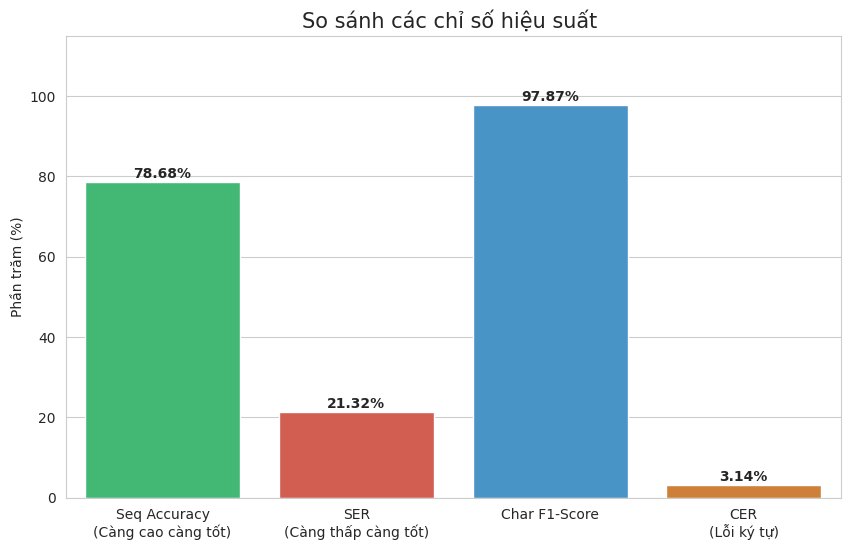

✅ Đã lưu biểu đồ tròn SER tại: /content/drive/MyDrive/crnn_licenseplate/accuracy_vs_ser_pie.png


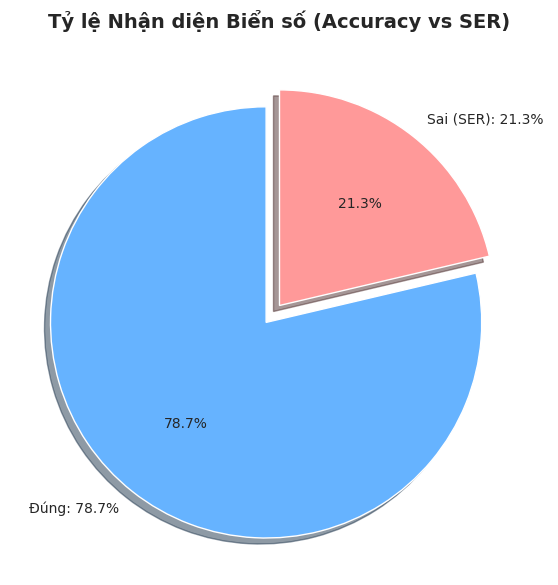


📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...


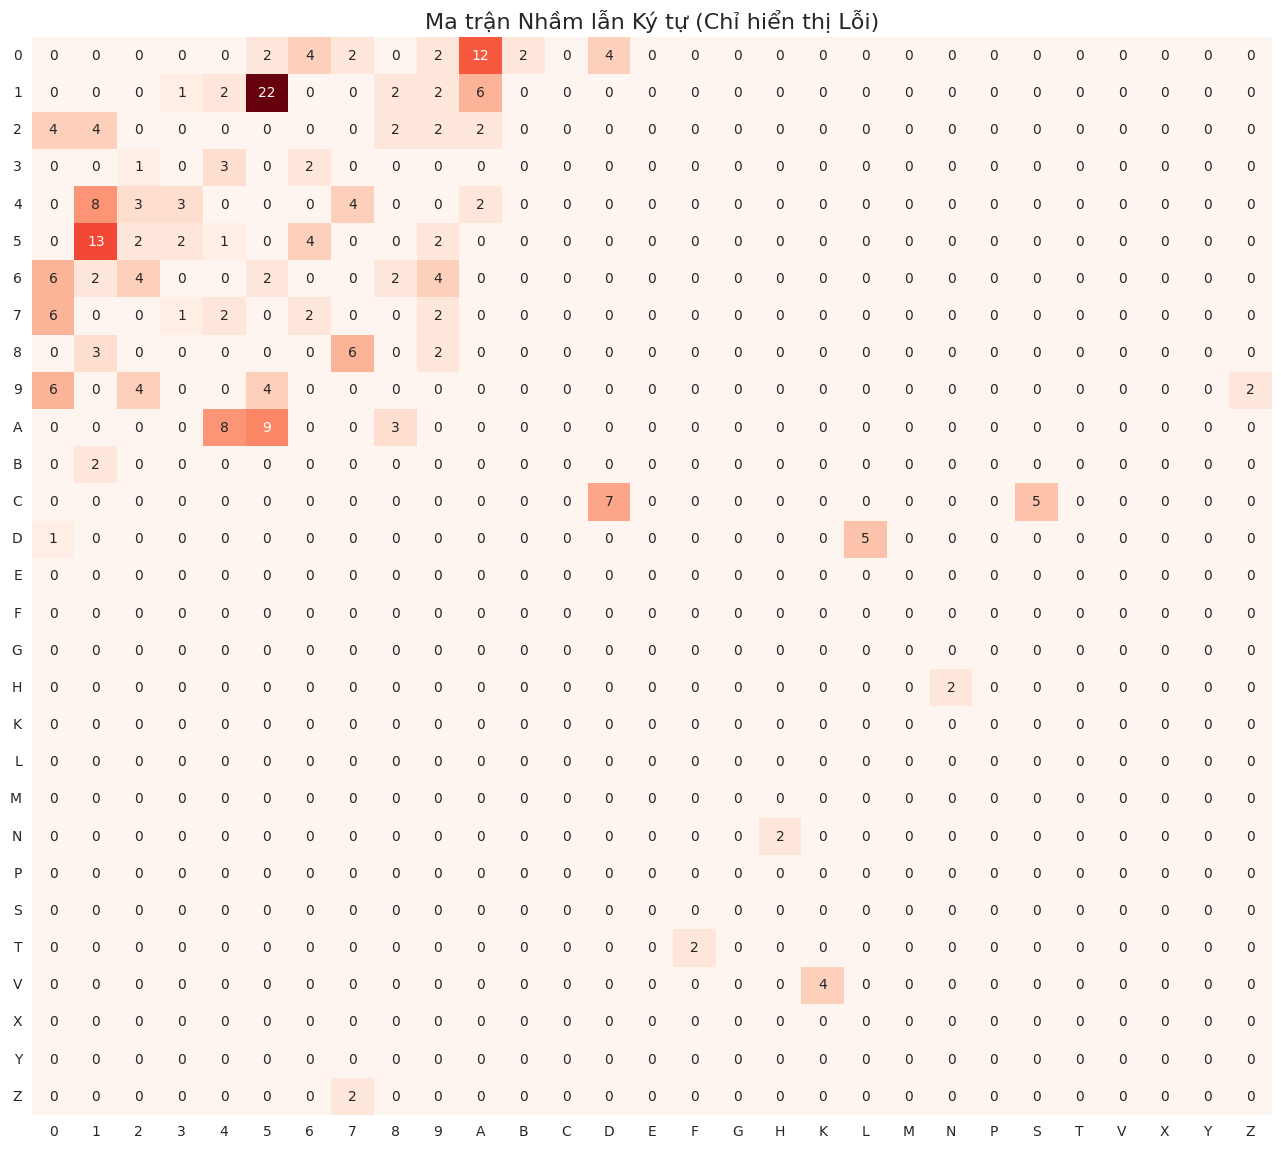

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import editdistance
from tqdm import tqdm
import difflib
from sklearn.metrics import confusion_matrix
import os

# =============================================================================
# 1. CẤU HÌNH VÀ TẢI MÔ HÌNH
# =============================================================================
# Giả lập đường dẫn output_dir và val_loader nếu chạy độc lập (Bạn có thể xóa nếu chạy trong notebook cũ)
# output_dir = "/content/drive/MyDrive/crnn_licenseplate"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Tên model bạn muốn đánh giá
MODEL_FILE = "best_model_FINAL_robust_v2.pth"
model_path = f"{output_dir}/{MODEL_FILE}"

print(f"📊 ĐANG TẢI MÔ HÌNH TỪ: {model_path}")

if not os.path.exists(model_path):
    print(f"❌ Lỗi: Không tìm thấy file {model_path}")
else:
    checkpoint = torch.load(model_path, map_location=device)
    # Khởi tạo model (đảm bảo class CRNN đã được định nghĩa trước đó)
    model_eval = CRNN(num_classes=len(checkpoint['idx_to_char']), hidden_size=256, pretrained=False).to(device)
    model_eval.load_state_dict(checkpoint['model_state_dict'])
    model_eval.eval()
    idx_to_char = checkpoint['idx_to_char']

    def decode_predictions(outputs):
        _, preds = torch.max(outputs, dim=2)
        preds = preds.permute(1, 0)
        decoded = []
        for pred in preds:
            chars = []
            prev = -1
            for p in pred:
                p = p.item()
                if p != prev and p != 0:
                    chars.append(idx_to_char[p])
                prev = p
            decoded.append(''.join(chars))
        return decoded

    # =============================================================================
    # 2. TÍNH TOÁN CÁC CHỈ SỐ (BAO GỒM SER)
    # =============================================================================
    print("\n🚀 Đang chạy đánh giá...")

    total_samples = 0
    exact_matches = 0
    total_char_dist = 0
    total_chars_true = 0
    total_chars_pred = 0
    total_correct_chars = 0

    # Lists để vẽ Confusion Matrix
    y_true_chars = []
    y_pred_chars = []
    vocab_chars = sorted([c for c in idx_to_char.values() if c.isalnum()])

    with torch.no_grad():
        for batch in tqdm(val_loader):
            if batch is None: continue

            images = batch["images"].to(device)
            texts = batch["texts"]

            outputs = model_eval(images)
            preds = decode_predictions(outputs)

            for pred, target in zip(preds, texts):
                total_samples += 1

                # 1. Accuracy (Đúng tuyệt đối cả chuỗi)
                if pred == target: exact_matches += 1

                # 2. CER (Lỗi ký tự)
                dist = editdistance.eval(pred, target)
                total_char_dist += dist
                total_chars_true += len(target)
                total_chars_pred += len(pred)

                # 3. F1 Score prep
                s = difflib.SequenceMatcher(None, pred, target)
                matches = sum(n for i, j, n in s.get_matching_blocks())
                total_correct_chars += matches

                # 4. Data cho Confusion Matrix
                min_len = min(len(pred), len(target))
                for i in range(min_len):
                    y_true_chars.append(target[i])
                    y_pred_chars.append(pred[i])

    # --- TỔNG HỢP KẾT QUẢ ---
    # Tỷ lệ đoán đúng cả biển
    seq_accuracy = (exact_matches / total_samples) * 100

    # ✅ TÍNH SER (SEQUENCE ERROR RATE)
    ser = 100 - seq_accuracy

    # Tỷ lệ lỗi ký tự
    cer = (total_char_dist / total_chars_true) * 100

    # F1 Score
    precision = total_correct_chars / total_chars_pred if total_chars_pred > 0 else 0
    recall = total_correct_chars / total_chars_true if total_chars_true > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_score *= 100

    print("\n" + "="*60)
    print(f"🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT")
    print("="*60)
    print(f"1. Sequence Accuracy (Độ chính xác biển số):  {seq_accuracy:.2f}%")
    print(f"👉 SER (Tỷ lệ biển số bị sai):                 {ser:.2f}%")  # Đã thêm dòng này
    print("-" * 60)
    print(f"2. Character F1-Score:                        {f1_score:.2f}%")
    print(f"3. CER (Lỗi ký tự trung bình):                {cer:.2f}%")
    print("="*60)

    # =============================================================================
    # 3. VẼ BIỂU ĐỒ CỘT (CẬP NHẬT SER)
    # =============================================================================
    # Thêm SER vào DataFrame để vẽ
    metrics_df = pd.DataFrame({
        'Metric': ['Seq Accuracy\n(Càng cao càng tốt)', 'SER\n(Càng thấp càng tốt)', 'Char F1-Score', 'CER\n(Lỗi ký tự)'],
        'Score': [seq_accuracy, ser, f1_score, cer]
    })

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Vẽ biểu đồ với màu sắc khác biệt cho các chỉ số Tốt (Xanh) và Xấu (Đỏ)
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22'] # Xanh lá, Đỏ, Xanh dương, Cam
    ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette=colors)

    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.2f}%', ha="center", fontweight='bold')

    plt.ylim(0, 115)
    plt.title('So sánh các chỉ số hiệu suất ', fontsize=15)
    plt.ylabel('Phần trăm (%)')
    plt.xlabel('')

    save_chart_path = f"{output_dir}/evaluation_metrics_chart.png"
    plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
    plt.show()

    # =============================================================================
    # 3.1. VẼ BIỂU ĐỒ TRÒN (PIE CHART) CHO ACCURACY vs SER
    # =============================================================================
    # Biểu đồ này trực quan nhất để thấy tỷ lệ Sai (SER) so với Đúng
    plt.figure(figsize=(7, 7))
    labels = [f'Đúng: {seq_accuracy:.1f}%', f'Sai (SER): {ser:.1f}%']
    sizes = [seq_accuracy, ser]
    colors_pie = ['#66b3ff', '#ff9999'] # Xanh và Đỏ nhạt
    explode = (0.1, 0)  # Tách phần "Đúng" ra một chút

    plt.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90)
    plt.title("Tỷ lệ Nhận diện Biển số (Accuracy vs SER)", fontsize=14, fontweight='bold')

    save_pie_path = f"{output_dir}/accuracy_vs_ser_pie.png"
    plt.savefig(save_pie_path, dpi=300)
    print(f"✅ Đã lưu biểu đồ tròn SER tại: {save_pie_path}")
    plt.show()

    # =============================================================================
    # 4. CONFUSION MATRIX (GIỮ NGUYÊN)
    # =============================================================================
    # ... (Phần code vẽ Confusion Matrix của bạn giữ nguyên ở đây)
    print("\n📊 Đang tạo Ma trận Nhầm lẫn (Confusion Matrix)...")
    cm = confusion_matrix(y_true_chars, y_pred_chars, labels=vocab_chars)
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)

    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds',
                xticklabels=vocab_chars, yticklabels=vocab_chars, cbar=False)
    plt.title('Ma trận Nhầm lẫn Ký tự (Chỉ hiển thị Lỗi)', fontsize=16)
    plt.xticks(rotation=0); plt.yticks(rotation=0)
    plt.show()